# 07 · Pre-optimization model profiling

**Single responsibility:** profile the frozen trained model's layers, sparsity, compute, and memory before any pruning or quantization

Run after the preceding numbered notebook unless the inputs already exist. Every generated artifact is written outside the notebook so this stage is reproducible.


## Scope and interpretation

This notebook is deliberately **read-only with respect to the model**. It profiles the best trained float32 checkpoint before manual optimization. Exact-zero sparsity measures existing zeros; it does not imply that small nonzero weights can be removed safely. Memory figures are structural graph estimates, not TensorFlow process RSS or a later TFLite Micro tensor-arena measurement.

In [1]:
from pathlib import Path
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'configs/base.yaml').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from vww_esp32.config import load_config, resolve_paths, seed_everything

config, ROOT = load_config(ROOT / 'configs/base.yaml')
paths = resolve_paths(config, ROOT)
seed_everything(config['project']['seed'])
ROOT


PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32')

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import Markdown, display
from matplotlib.ticker import PercentFormatter

from vww_esp32.profiling import human_bytes, profile_model

sns.set_theme(style='whitegrid', context='notebook', font_scale=0.95)
COLORS = {'parameters': '#355C7D', 'macs': '#F67280', 'activation': '#6C5B7B', 'int8': '#2A9D8F'}
checkpoint = paths['artifacts'] / 'checkpoints' / 'best.keras'
assert checkpoint.exists(), f'Missing trained checkpoint: {checkpoint}'
model = tf.keras.models.load_model(checkpoint, compile=False)
print(f'Checkpoint: {checkpoint}')
print(f'Checkpoint file: {human_bytes(checkpoint.stat().st_size)}')
model.summary()

Checkpoint: /Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/checkpoints/best.keras
Checkpoint file: 1.54 MiB


Model: "tiny_mobilenet_v1_0.25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalize (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment_flip (RandomFlip)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment_shift                   │ (None, 96, 96, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv (Conv2D)              │ (None, 48, 48, 8)      │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_bn (BatchNormalization)    │ (None, 48, 48, 8)      │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_relu6 (ReLU)               │ (None, 48, 48, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dw (DepthwiseConv2D)     │ (None, 48, 48, 8)      │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dw_bn                    │ (None, 48, 48, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dw_relu6 (ReLU)          │ (None, 48, 48, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pw (Conv2D)              │ (None, 48, 48, 16)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pw_bn                    │ (None, 48, 48, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pw_relu6 (ReLU)          │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dw (DepthwiseConv2D)     │ (None, 24, 24, 16)     │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dw_bn                    │ (None, 24, 24, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dw_relu6 (ReLU)          │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pw (Conv2D)              │ (None, 24, 24, 32)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pw_bn                    │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pw_relu6 (ReLU)          │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_dw (DepthwiseConv2D)     │ (None, 24, 24, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_dw_bn                    │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_dw_relu6 (ReLU)          │ (None, 24, 24, 32)     │             

 Total params: 111,793 (436.69 KB)

 Trainable params: 108,369 (423.32 KB)

 Non-trainable params: 3,424 (13.38 KB)

## 1. Executive resource summary

In [4]:
layer_profile, memory_trace, profile_summary = profile_model(
    model,
    batch_size=1,
    training_batch_size=config['preprocessing']['batch_size'],
    near_zero_threshold=1e-6,
)

summary_view = pd.DataFrame({
    'Metric': [
        'Layers', 'Total parameters', 'Trainable parameters', 'Non-trainable parameters',
        'Float32 weight memory', 'Estimated MACs / image', 'Global weight sparsity',
        'Kernel sparsity', 'Kernel near-zero fraction (|w| ≤ 1e-6)',
        'Peak live float32 activations (batch 1)', 'Hypothetical INT8 activation peak',
        'Float32 weights + peak activations (combined)',
        f"Training structural estimate (batch {profile_summary['training_batch_size_for_estimate']})",
    ],
    'Value': [
        f"{profile_summary['layers']:,}",
        f"{profile_summary['parameters']:,}",
        f"{profile_summary['trainable_parameters']:,}",
        f"{profile_summary['non_trainable_parameters']:,}",
        human_bytes(profile_summary['float32_weight_bytes']),
        f"{profile_summary['estimated_macs_batch1'] / 1e6:.3f} M",
        f"{profile_summary['global_weight_sparsity']:.3%}",
        f"{profile_summary['global_kernel_sparsity']:.3%}",
        f"{profile_summary['global_kernel_near_zero_fraction']:.4%}",
        human_bytes(profile_summary['peak_live_activation_float32_bytes_batch1']),
        human_bytes(profile_summary['peak_live_activation_int8_bytes_batch1_hypothetical']),
        human_bytes(profile_summary['float32_inference_structural_bytes']),
        human_bytes(profile_summary['training_structural_bytes_estimate']),
    ],
})
display(summary_view.style.hide(axis='index').set_properties(**{'text-align': 'left'}))
print('Peak activation occurs at:', profile_summary['peak_live_activation_layer'])
print('Caveat:', profile_summary['memory_estimate_scope'])

Metric,Value
Layers,70
Total parameters,"111,793"
Trainable parameters,"108,369"
Non-trainable parameters,"3,424"
Float32 weight memory,436.69 KiB
Estimated MACs / image,5.616 M
Global weight sparsity,0.000%
Kernel sparsity,0.000%
Kernel near-zero fraction (|w| ≤ 1e-6),0.0029%
Peak live float32 activations (batch 1),288.00 KiB


Peak activation occurs at: block1_pw_bn
Caveat: Static graph estimate, not an ESP32 SRAM or tensor-arena measurement. Weights and activations may occupy different memory regions; fusion, in-place reuse, kernel workspace, allocator fragmentation, and runtime overhead are not modeled.


## 2. Layer-by-layer inventory

In [5]:
inventory_columns = [
    'layer_index', 'layer_name', 'layer_type', 'stage', 'input_shape', 'output_shape',
    'parameters', 'trainable_parameters', 'non_trainable_parameters', 'weight_sparsity',
    'near_zero_fraction', 'output_float32_bytes_batch1', 'estimated_macs_batch1',
]
with pd.option_context('display.max_rows', 100, 'display.max_colwidth', 40):
    display(
        layer_profile[inventory_columns].style
        .format({
            'parameters': '{:,.0f}',
            'trainable_parameters': '{:,.0f}',
            'non_trainable_parameters': '{:,.0f}',
            'weight_sparsity': '{:.2%}',
            'near_zero_fraction': '{:.2%}',
            'output_float32_bytes_batch1': '{:,.0f}',
            'estimated_macs_batch1': '{:,.0f}',
        }, na_rep='—')
        .background_gradient(subset=['parameters'], cmap='Blues')
        .background_gradient(subset=['estimated_macs_batch1'], cmap='Reds')
        .background_gradient(subset=['output_float32_bytes_batch1'], cmap='Purples')
    )

,layer_index,layer_name,layer_type,stage,input_shape,output_shape,parameters,trainable_parameters,non_trainable_parameters,weight_sparsity,near_zero_fraction,output_float32_bytes_batch1,estimated_macs_batch1
0,0,image,InputLayer,input,—,"(None, 96, 96, 3)",0,0,0,—,—,"110,592",0
1,1,normalize,Rescaling,preprocess,"(None, 96, 96, 3)","(None, 96, 96, 3)",0,0,0,—,—,"110,592",0
2,2,augment_flip,RandomFlip,preprocess,"(None, 96, 96, 3)","(None, 96, 96, 3)",0,0,0,—,—,"110,592",0
3,3,augment_shift,RandomTranslation,preprocess,"(None, 96, 96, 3)","(None, 96, 96, 3)",0,0,0,—,—,"110,592",0
4,4,stem_conv,Conv2D,stem,"(None, 96, 96, 3)","(None, 48, 48, 8)",216,216,0,0.00%,0.00%,"73,728","497,664"
5,5,stem_bn,BatchNormalization,stem,"(None, 48, 48, 8)","(None, 48, 48, 8)",32,16,16,0.00%,0.00%,"73,728",0
6,6,stem_relu6,ReLU,stem,"(None, 48, 48, 8)","(None, 48, 48, 8)",0,0,0,—,—,"73,728",0
7,7,block1_dw,DepthwiseConv2D,block1,"(None, 48, 48, 8)","(None, 48, 48, 8)",72,72,0,0.00%,0.00%,"73,728","165,888"
8,8,block1_dw_bn,BatchNormalization,block1,"(None, 48, 48, 8)","(None, 48, 48, 8)",32,16,16,0.00%,0.00%,"73,728",0
9,9,block1_dw_relu6,ReLU,block1,"(None, 48, 48, 8)","(None, 48, 48, 8)",0,0,0,—,—,"73,728",0


In [5]:
stage_profile = (
    layer_profile.groupby('stage', sort=False)
    .agg(
        layers=('layer_name', 'count'),
        parameters=('parameters', 'sum'),
        weight_bytes=('weight_bytes', 'sum'),
        output_float32_bytes=('output_float32_bytes_batch1', 'sum'),
        estimated_macs=('estimated_macs_batch1', 'sum'),
    )
    .assign(
        parameter_share=lambda frame: frame.parameters / frame.parameters.sum(),
        mac_share=lambda frame: frame.estimated_macs / frame.estimated_macs.sum(),
    )
)
display(stage_profile.style.format({
    'parameters': '{:,.0f}', 'weight_bytes': '{:,.0f}',
    'output_float32_bytes': '{:,.0f}', 'estimated_macs': '{:,.0f}',
    'parameter_share': '{:.1%}', 'mac_share': '{:.1%}',
}).background_gradient(subset=['parameter_share', 'mac_share'], cmap='YlOrRd'))

,layers,parameters,weight_bytes,output_float32_bytes,estimated_macs,parameter_share,mac_share
stage,,,,,,,
input,1,0,0,"110,592",0,0.0%,0.0%
preprocess,3,0,0,"331,776",0,0.0%,0.0%
stem,3,248,992,"221,184","497,664",0.2%,8.9%
block1,6,296,"1,184","663,552","460,800",0.3%,8.2%
block2,6,848,"3,392","331,776","377,856",0.8%,6.7%
block3,6,"1,568","6,272","442,368","755,712",1.4%,13.5%
block4,6,"2,720","10,880","165,888","336,384",2.4%,6.0%
block5,6,"5,184","20,736","221,184","672,768",4.6%,12.0%
block6,6,"9,536","38,144","82,944","315,648",8.5%,5.6%


## 3. Resource concentration dashboard

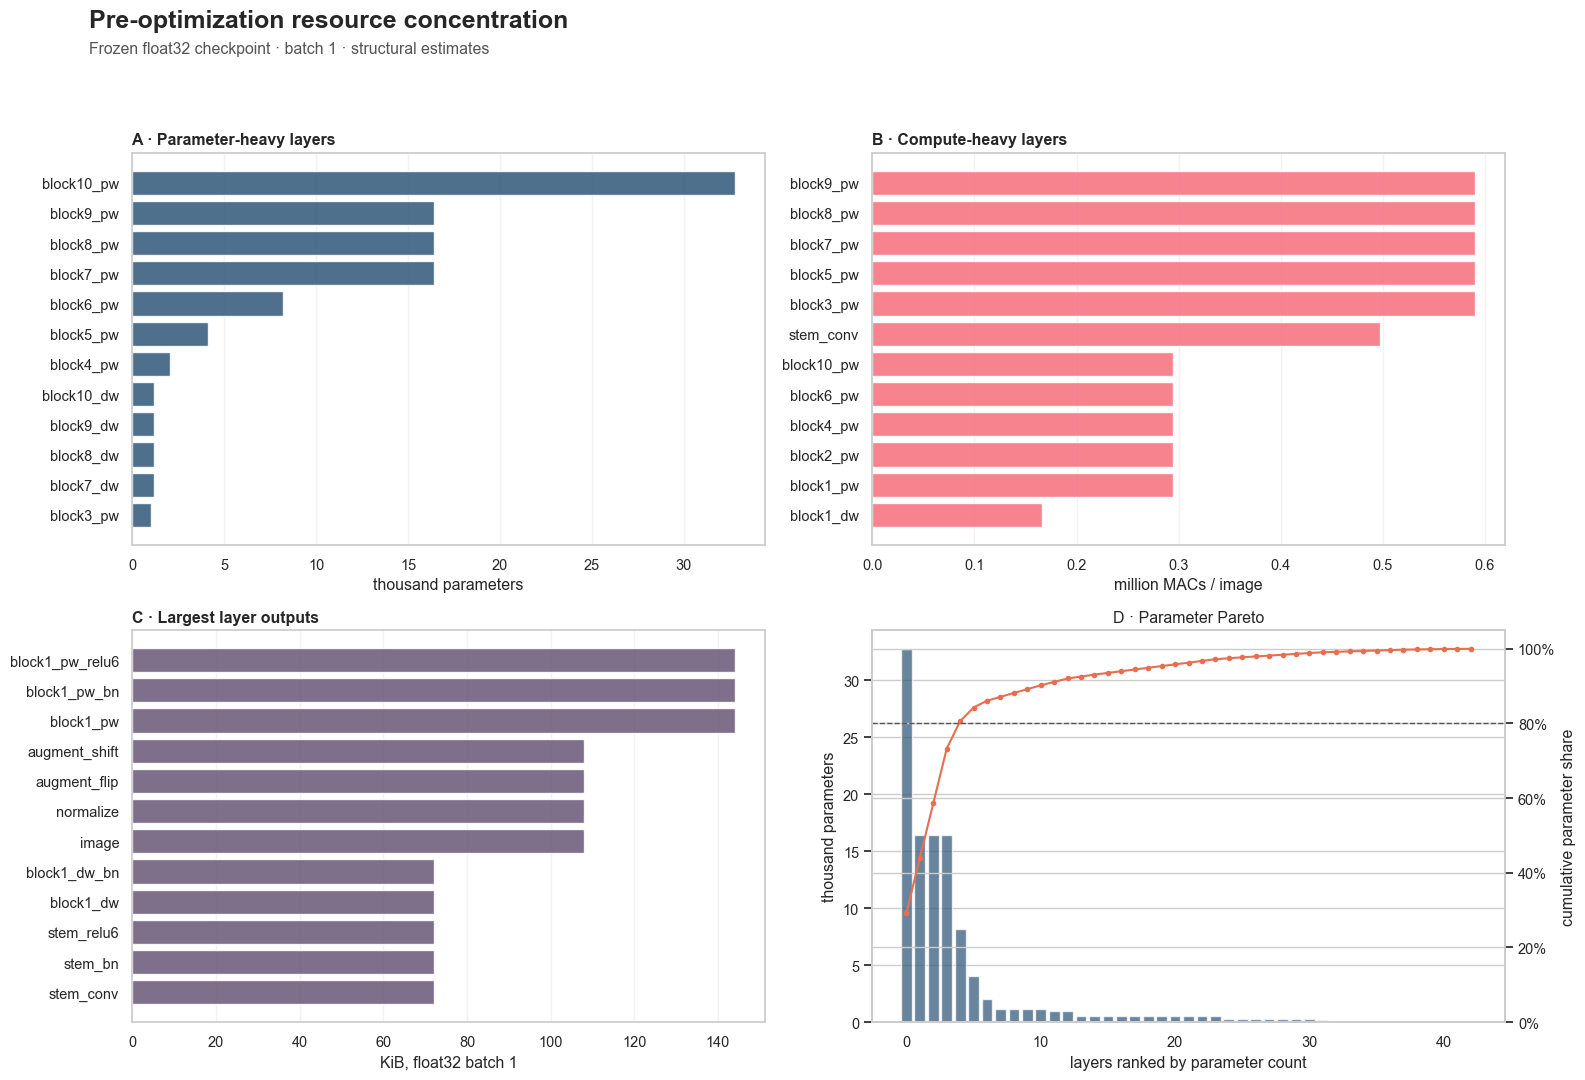

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Pre-optimization resource concentration', fontsize=18, fontweight='bold', x=0.06, ha='left')
fig.text(0.06, 0.94, 'Frozen float32 checkpoint · batch 1 · structural estimates', color='#555555')

def horizontal_top(axis, column, color, title, unit_scale=1, suffix=''):
    top = layer_profile.nlargest(12, column).sort_values(column)
    values = top[column] / unit_scale
    axis.barh(top.layer_name, values, color=color, alpha=0.88)
    axis.set_title(title, loc='left', fontweight='bold')
    axis.set_xlabel(suffix)
    axis.grid(axis='x', alpha=0.25)
    axis.grid(axis='y', visible=False)

horizontal_top(axes[0, 0], 'parameters', COLORS['parameters'], 'A · Parameter-heavy layers', 1e3, 'thousand parameters')
horizontal_top(axes[0, 1], 'estimated_macs_batch1', COLORS['macs'], 'B · Compute-heavy layers', 1e6, 'million MACs / image')
horizontal_top(axes[1, 0], 'output_float32_bytes_batch1', COLORS['activation'], 'C · Largest layer outputs', 1024, 'KiB, float32 batch 1')

pareto = layer_profile[layer_profile.parameters > 0].sort_values('parameters', ascending=False).copy()
pareto['cumulative'] = pareto.parameters.cumsum() / pareto.parameters.sum()
axes[1, 1].bar(range(len(pareto)), pareto.parameters / 1e3, color=COLORS['parameters'], alpha=0.75)
pareto_axis = axes[1, 1].twinx()
pareto_axis.plot(range(len(pareto)), pareto.cumulative, color='#E76F51', marker='o', markersize=3)
pareto_axis.axhline(0.8, color='#555555', linestyle='--', linewidth=1)
pareto_axis.yaxis.set_major_formatter(PercentFormatter(1))
pareto_axis.set_ylim(0, 1.05)
axes[1, 1].set(title='D · Parameter Pareto', xlabel='layers ranked by parameter count', ylabel='thousand parameters')
pareto_axis.set_ylabel('cumulative parameter share')
axes[1, 1].grid(axis='x', visible=False)

plt.tight_layout(rect=(0, 0, 1, 0.92))
overview_path = paths['artifacts'] / 'figures' / 'pre_optimization_resource_dashboard.png'
fig.savefig(overview_path, dpi=180, bbox_inches='tight')
plt.show()

## 4. Architecture shape and optimization opportunity map

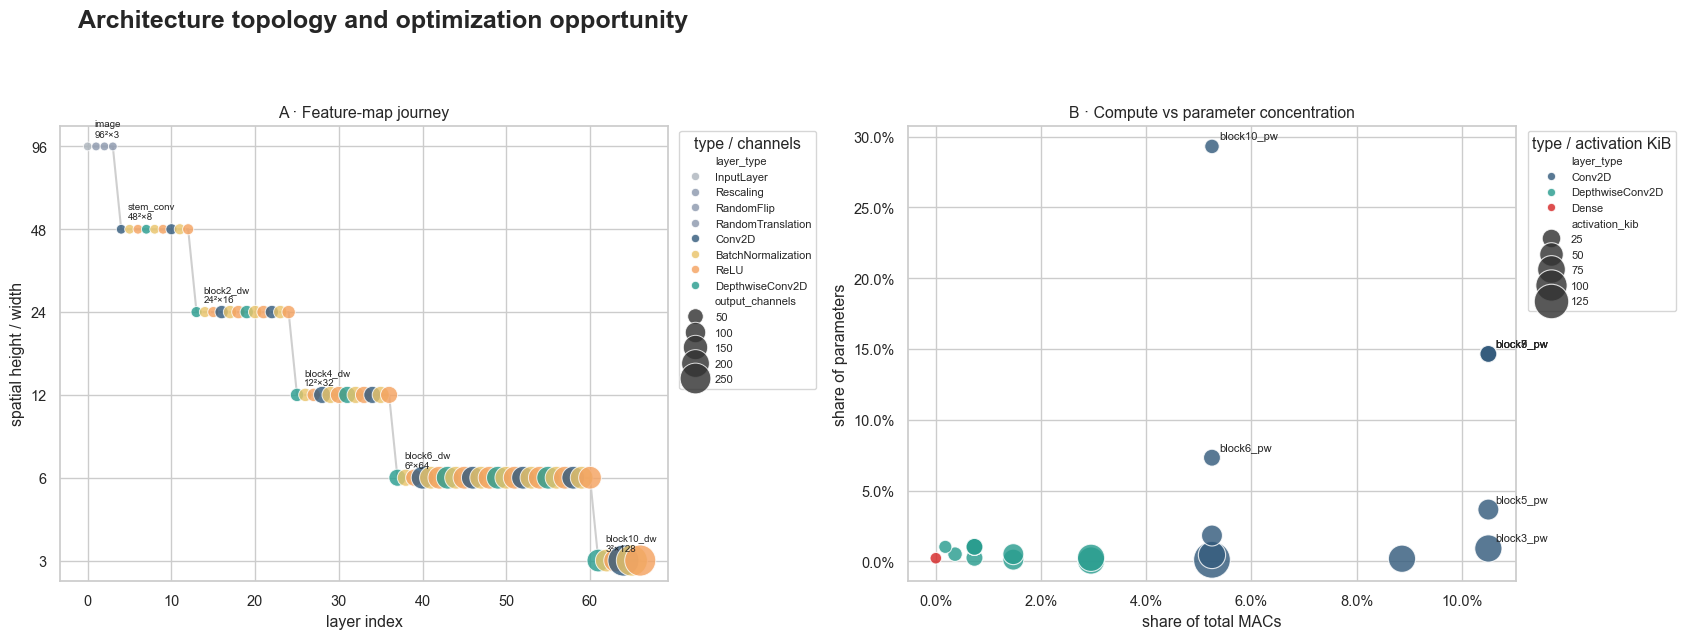

In [7]:
spatial = layer_profile.dropna(subset=['output_height', 'output_channels']).copy()
spatial['activation_kib'] = spatial.output_float32_bytes_batch1 / 1024
type_palette = {
    'InputLayer': '#ADB5BD', 'Conv2D': '#355C7D', 'DepthwiseConv2D': '#2A9D8F',
    'BatchNormalization': '#E9C46A', 'ReLU': '#F4A261', 'Dense': '#D62828',
    'Rescaling': '#8D99AE', 'RandomFlip': '#8D99AE', 'RandomTranslation': '#8D99AE',
}
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
fig.suptitle('Architecture topology and optimization opportunity', fontsize=18, fontweight='bold', x=0.05, ha='left')

sns.scatterplot(
    data=spatial, x='layer_index', y='output_height', size='output_channels', hue='layer_type',
    sizes=(40, 500), palette=type_palette, alpha=0.82, edgecolor='white', linewidth=0.7, ax=axes[0],
)
axes[0].plot(spatial.layer_index, spatial.output_height, color='#777777', alpha=0.35, zorder=0)
axes[0].set_yscale('log', base=2)
axes[0].set_yticks([3, 6, 12, 24, 48, 96], labels=[3, 6, 12, 24, 48, 96])
axes[0].set(title='A · Feature-map journey', xlabel='layer index', ylabel='spatial height / width')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, title='type / channels')
changes = spatial[spatial.output_height.ne(spatial.output_height.shift())]
for row in changes.itertuples():
    axes[0].annotate(f'{row.layer_name}\n{int(row.output_height)}²×{int(row.output_channels)}',
                     (row.layer_index, row.output_height), xytext=(5, 7), textcoords='offset points', fontsize=7)

resource_layers = layer_profile[layer_profile.estimated_macs_batch1 > 0].copy()
resource_layers['activation_kib'] = resource_layers.output_float32_bytes_batch1 / 1024
sns.scatterplot(
    data=resource_layers, x='estimated_macs_batch1_share', y='parameters_share',
    size='activation_kib', hue='layer_type', sizes=(70, 700), palette=type_palette,
    alpha=0.82, edgecolor='white', linewidth=0.8, ax=axes[1],
)
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set(title='B · Compute vs parameter concentration', xlabel='share of total MACs', ylabel='share of parameters')
label_indices = set(resource_layers.nlargest(5, 'estimated_macs_batch1').index) | set(resource_layers.nlargest(5, 'parameters').index)
for index in label_indices:
    row = resource_layers.loc[index]
    axes[1].annotate(row.layer_name, (row.estimated_macs_batch1_share, row.parameters_share),
                     xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, title='type / activation KiB')
plt.tight_layout(rect=(0, 0, 1, 0.92))
opportunity_path = paths['artifacts'] / 'figures' / 'pre_optimization_opportunity_map.png'
fig.savefig(opportunity_path, dpi=180, bbox_inches='tight')
plt.show()

## 5. Existing sparsity and weight-magnitude evidence

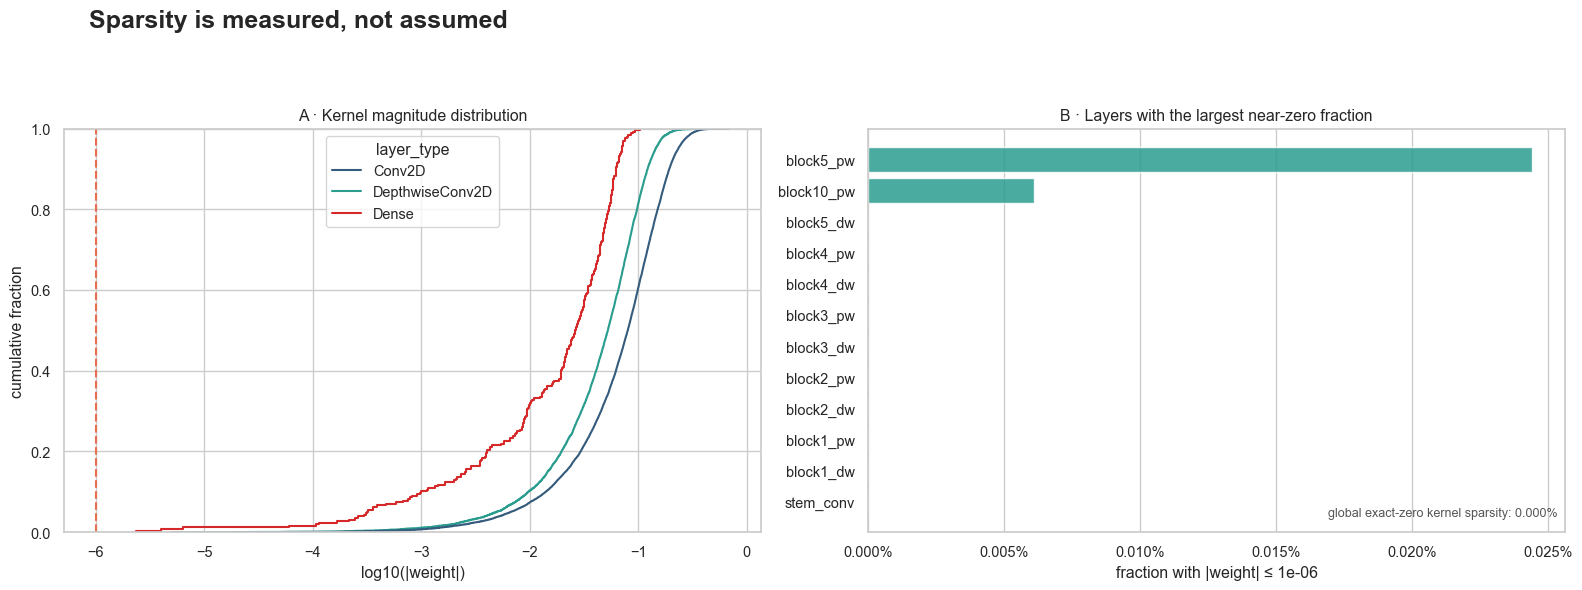

Exact-zero sparsity across kernels: 0.0000%
Near-zero kernel fraction: 0.0029%
Interpretation: dense nonzero kernels do not become smaller without pruning/retraining and sparse-runtime support.


In [8]:
rng = np.random.default_rng(config['project']['seed'])
magnitude_rows = []
for layer in model.layers:
    for variable in layer.trainable_weights:
        if len(variable.shape) < 2 or 'kernel' not in variable.name.lower():
            continue
        values = np.abs(variable.numpy()).reshape(-1)
        if len(values) > 2500:
            values = rng.choice(values, size=2500, replace=False)
        magnitude_rows.extend({
            'layer_name': layer.name, 'layer_type': layer.__class__.__name__,
            'log10_abs_weight': np.log10(float(value) + 1e-12),
        } for value in values)
weight_magnitudes = pd.DataFrame(magnitude_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sparsity is measured, not assumed', fontsize=18, fontweight='bold', x=0.06, ha='left')
sns.ecdfplot(data=weight_magnitudes, x='log10_abs_weight', hue='layer_type', palette=type_palette, ax=axes[0])
axes[0].axvline(-6, color='#E76F51', linestyle='--', label='near-zero threshold')
axes[0].set(title='A · Kernel magnitude distribution', xlabel='log10(|weight|)', ylabel='cumulative fraction')

kernel_layers = layer_profile.dropna(subset=['kernel_sparsity']).copy()
near_zero_top = kernel_layers.nlargest(12, 'near_zero_fraction').sort_values('near_zero_fraction')
axes[1].barh(near_zero_top.layer_name, near_zero_top.near_zero_fraction, color='#2A9D8F', alpha=0.85)
axes[1].xaxis.set_major_formatter(PercentFormatter(1, decimals=3))
axes[1].set(
    title='B · Layers with the largest near-zero fraction',
    xlabel=f"fraction with |weight| ≤ {profile_summary['near_zero_threshold']:.0e}",
    ylabel='',
)
axes[1].grid(axis='y', visible=False)
axes[1].text(
    0.99, 0.04, f"global exact-zero kernel sparsity: {profile_summary['global_kernel_sparsity']:.3%}",
    transform=axes[1].transAxes, ha='right', color='#555555', fontsize=9,
)
plt.tight_layout(rect=(0, 0, 1, 0.91))
sparsity_path = paths['artifacts'] / 'figures' / 'pre_optimization_sparsity.png'
fig.savefig(sparsity_path, dpi=180, bbox_inches='tight')
plt.show()

print(f"Exact-zero sparsity across kernels: {profile_summary['global_kernel_sparsity']:.4%}")
print(f"Near-zero kernel fraction: {profile_summary['global_kernel_near_zero_fraction']:.4%}")
print('Interpretation: dense nonzero kernels do not become smaller without pruning/retraining and sparse-runtime support.')

## 6. Peak activation liveness and memory scenarios

Scenario,Readable
Float32 weights,436.69 KiB
"Peak live float32 activations, batch 1",288.00 KiB
Float32 weights + peak activations (combined),724.69 KiB
"Hypothetical INT8 live activations, batch 1",72.00 KiB
"Float32 training structural estimate, batch 64",181.51 MiB


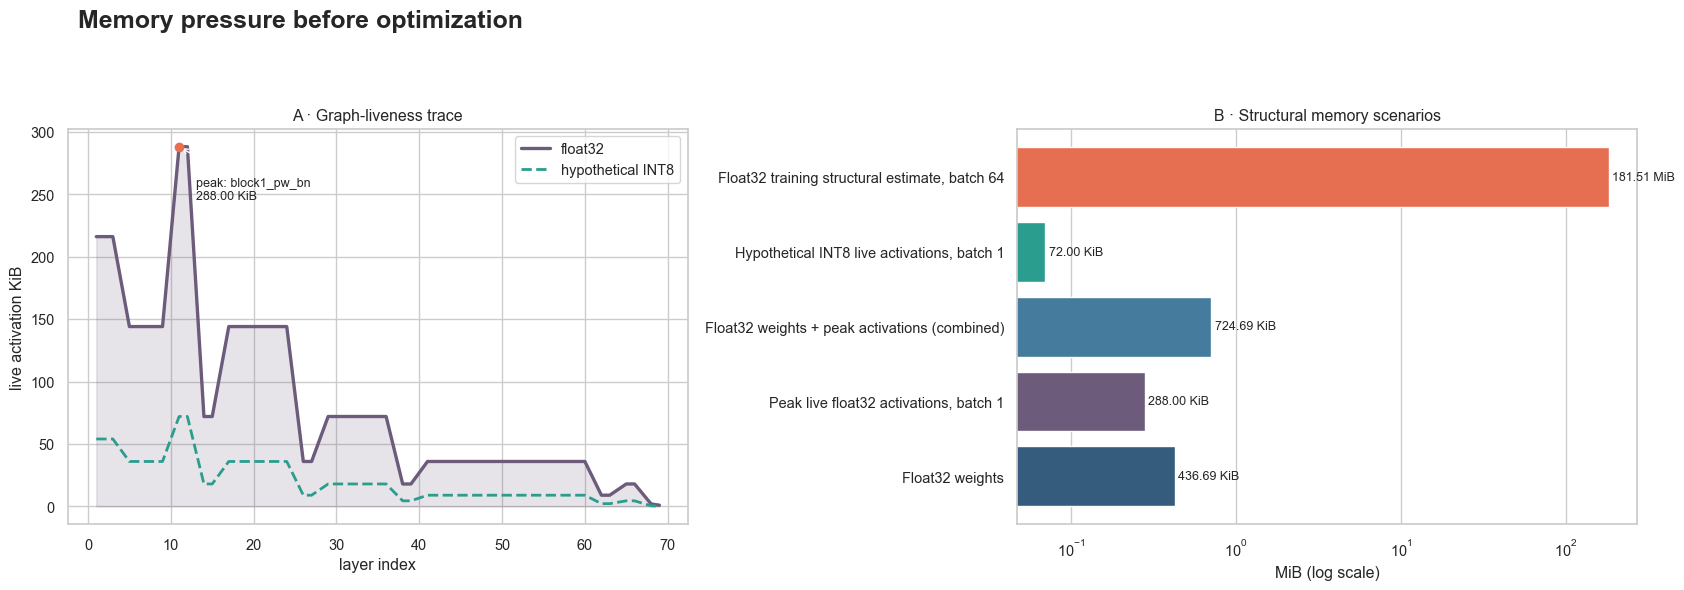

In [9]:
peak_row = memory_trace.loc[memory_trace.live_float32_bytes.idxmax()]
memory_table = pd.DataFrame({
    'Scenario': [
        'Float32 weights', 'Peak live float32 activations, batch 1',
        'Float32 weights + peak activations (combined)', 'Hypothetical INT8 live activations, batch 1',
        f"Float32 training structural estimate, batch {profile_summary['training_batch_size_for_estimate']}",
    ],
    'Bytes': [
        profile_summary['float32_weight_bytes'],
        profile_summary['peak_live_activation_float32_bytes_batch1'],
        profile_summary['float32_inference_structural_bytes'],
        profile_summary['peak_live_activation_int8_bytes_batch1_hypothetical'],
        profile_summary['training_structural_bytes_estimate'],
    ],
})
memory_table['Readable'] = memory_table.Bytes.map(human_bytes)
display(memory_table[['Scenario', 'Readable']].style.hide(axis='index'))

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Memory pressure before optimization', fontsize=18, fontweight='bold', x=0.05, ha='left')
axes[0].plot(memory_trace.layer_index, memory_trace.live_float32_bytes / 1024,
             color=COLORS['activation'], linewidth=2.4, label='float32')
axes[0].fill_between(memory_trace.layer_index, memory_trace.live_float32_bytes / 1024,
                     color=COLORS['activation'], alpha=0.16)
axes[0].plot(memory_trace.layer_index, memory_trace.live_int8_bytes_hypothetical / 1024,
             color=COLORS['int8'], linewidth=2, linestyle='--', label='hypothetical INT8')
axes[0].scatter([peak_row.layer_index], [peak_row.live_float32_bytes / 1024], color='#E76F51', zorder=5)
axes[0].annotate(f"peak: {peak_row.layer_name}\n{human_bytes(peak_row.live_float32_bytes)}",
                 (peak_row.layer_index, peak_row.live_float32_bytes / 1024),
                 xytext=(12, -38), textcoords='offset points', arrowprops={'arrowstyle': '->'}, fontsize=9)
axes[0].set(title='A · Graph-liveness trace', xlabel='layer index', ylabel='live activation KiB')
axes[0].legend()

plot_memory = memory_table.copy()
plot_memory['MiB'] = plot_memory.Bytes / 1024**2
axes[1].barh(plot_memory.Scenario, plot_memory.MiB, color=['#355C7D', '#6C5B7B', '#457B9D', '#2A9D8F', '#E76F51'])
axes[1].set_xscale('log')
axes[1].set(title='B · Structural memory scenarios', xlabel='MiB (log scale)')
axes[1].grid(axis='y', visible=False)
for index, row in plot_memory.iterrows():
    axes[1].text(row.MiB * 1.05, index, row.Readable, va='center', fontsize=9)
plt.tight_layout(rect=(0, 0, 1, 0.91))
memory_path = paths['artifacts'] / 'figures' / 'pre_optimization_memory.png'
fig.savefig(memory_path, dpi=180, bbox_inches='tight')
plt.show()

## 7. Evidence-led optimization priorities

In [10]:
top_parameter = layer_profile.nlargest(1, 'parameters').iloc[0]
top_compute = layer_profile.nlargest(1, 'estimated_macs_batch1').iloc[0]
top_activation = layer_profile.nlargest(1, 'output_float32_bytes_batch1').iloc[0]
parameter_layers_for_80 = int((layer_profile.sort_values('parameters', ascending=False).parameters.cumsum() / layer_profile.parameters.sum() < .8).sum() + 1)

display(Markdown(f"""
### Baseline diagnosis

- **Parameter bottleneck:** `{top_parameter.layer_name}` contains {top_parameter.parameters:,} parameters ({top_parameter.parameters_share:.1%} of the model).
- **Compute bottleneck:** `{top_compute.layer_name}` performs about {top_compute.estimated_macs_batch1 / 1e6:.3f} M MACs ({top_compute.estimated_macs_batch1_share:.1%} of total).
- **Activation bottleneck:** `{top_activation.layer_name}` emits {human_bytes(top_activation.output_float32_bytes_batch1)} at batch 1. Graph liveness peaks near `{profile_summary['peak_live_activation_layer']}`.
- **Concentration:** {parameter_layers_for_80} layers account for roughly 80% of parameters.
- **Natural sparsity:** kernel exact-zero sparsity is {profile_summary['global_kernel_sparsity']:.3%}; the checkpoint is effectively dense.

### Recommended experiment order

1. Reduce channels in the parameter-heavy 1×1 pointwise convolutions and retrain; this is structured and deployable.
2. Test a smaller input resolution or earlier downsampling against recall for small people; this targets early activation memory and MACs.
3. Fold BatchNorm for inference, then compare numerically before any quantization.
4. If pruning is tested, prefer channel/filter pruning with fine-tuning; unstructured zeros only help when the target runtime has sparse kernels.
5. Quantize only after the float32 architecture frontier is chosen, using representative ESP32-camera-domain frames.

No optimization is applied in this notebook. Each future variant should be compared against this frozen baseline.
"""))


### Baseline diagnosis

- **Parameter bottleneck:** `block10_pw` contains 32,768 parameters (29.3% of the model).
- **Compute bottleneck:** `block3_pw` performs about 0.590 M MACs (10.5% of total).
- **Activation bottleneck:** `block1_pw` emits 144.00 KiB at batch 1. Graph liveness peaks near `block1_pw_bn`.
- **Concentration:** 5 layers account for roughly 80% of parameters.
- **Natural sparsity:** kernel exact-zero sparsity is 0.000%; the checkpoint is effectively dense.

### Recommended experiment order

1. Reduce channels in the parameter-heavy 1×1 pointwise convolutions and retrain; this is structured and deployable.
2. Test a smaller input resolution or earlier downsampling against recall for small people; this targets early activation memory and MACs.
3. Fold BatchNorm for inference, then compare numerically before any quantization.
4. If pruning is tested, prefer channel/filter pruning with fine-tuning; unstructured zeros only help when the target runtime has sparse kernels.
5. Quantize only after the float32 architecture frontier is chosen, using representative ESP32-camera-domain frames.

No optimization is applied in this notebook. Each future variant should be compared against this frozen baseline.


## 8. Persist the profiling baseline

In [11]:
report_dir = paths['artifacts'] / 'reports'
figure_dir = paths['artifacts'] / 'figures'
report_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)
profile_summary.update({
    'checkpoint': str(checkpoint),
    'checkpoint_bytes': checkpoint.stat().st_size,
    'profile_status': 'pre_optimization_float32_baseline',
})
layer_path = report_dir / 'model_layer_profile.csv'
liveness_path = report_dir / 'model_memory_liveness.csv'
summary_path = report_dir / 'model_profile_summary.json'
layer_profile.to_csv(layer_path, index=False)
memory_trace.to_csv(liveness_path, index=False)
summary_path.write_text(json.dumps(profile_summary, indent=2))
{
    'summary': str(summary_path),
    'layer_profile': str(layer_path),
    'memory_trace': str(liveness_path),
    'figures': [str(overview_path), str(opportunity_path), str(sparsity_path), str(memory_path)],
}

{'summary': '/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/reports/model_profile_summary.json',
 'layer_profile': '/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/reports/model_layer_profile.csv',
 'memory_trace': '/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/reports/model_memory_liveness.csv',
 'figures': ['/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/figures/pre_optimization_resource_dashboard.png',
  '/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/figures/pre_optimization_opportunity_map.png',
  '/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/figures/pre_optimization_sparsity.png',
  '/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/figures/pre_optimization_memory.png']}